# Solving the Linear Transport (Advection) Equation: Numerical Methods vs. Neural Networks

This notebook solves the **1D Linear Transport Equation** (also called the advection equation) using:

1. **Numerical Methods** — Upwind scheme and Lax-Wendroff scheme (Finite Difference)
2. **Neural Network** — Physics-Informed Neural Network (PINN) via PyTorch

---

## Problem Statement

The linear transport equation in 1D:

$$\frac{\partial u}{\partial t} + c\,\frac{\partial u}{\partial x} = 0, \quad x \in [0, 1],\; t \in [0, T]$$

where $c > 0$ is the constant wave speed. The solution is a wave that propagates to the right at speed $c$ without changing shape.

**Conditions:**

| Type | Expression |
|------|-----------|
| Initial condition | $u(x, 0) = \sin(2\pi x)$ |
| Periodic BC | $u(0, t) = u(1, t)$ |

**Exact solution** (periodic, travelling wave):

$$u^*(x, t) = \sin\!\bigl(2\pi(x - ct)\bigr)$$

**Numerical stability** — both finite-difference schemes require the **CFL condition**:

$$\nu = \frac{c\,\Delta t}{\Delta x} \leq 1$$


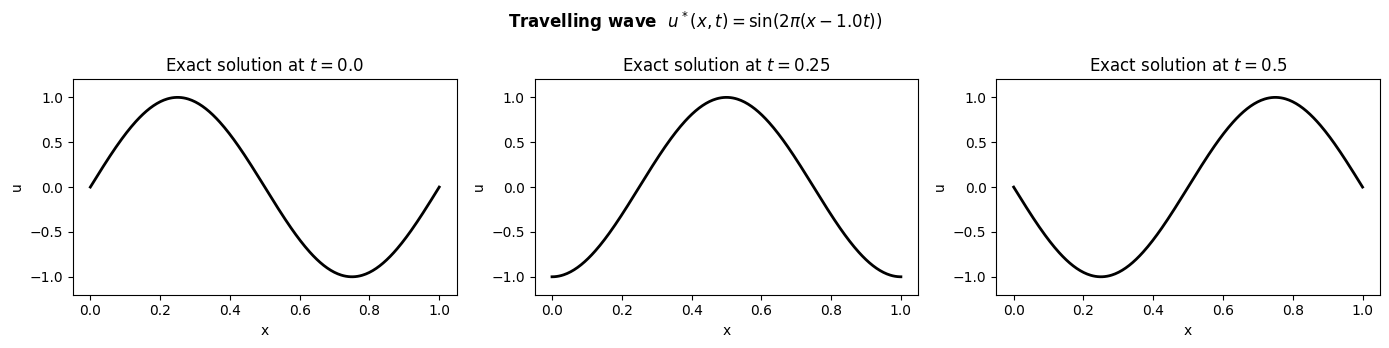

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.optim as optim

np.random.seed(42)
torch.manual_seed(42)

CMAP = "inferno"

# ---- Problem parameters ---------------------------------------------------
C  = 1.0   # wave speed
T  = 1.0   # final time
X0 = 0.0   # domain left
X1 = 1.0   # domain right

def u_exact(x, t, c=C):
    """Exact periodic travelling-wave solution: sin(2π(x − ct))."""
    return np.sin(2 * np.pi * (x - c * t))

def u_exact_torch(x, t, c=C):
    """Torch version of the exact solution."""
    return torch.sin(2 * torch.pi * (x - c * t))

# Quick preview of the exact solution
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
x_plot = np.linspace(0, 1, 300)
for ax, ti in zip(axes, [0.0, 0.25, 0.5]):
    ax.plot(x_plot, u_exact(x_plot, ti), color="black", lw=2)
    ax.set_title(f"Exact solution at $t = {ti}$")
    ax.set_xlabel("x"); ax.set_ylabel("u"); ax.set_ylim(-1.2, 1.2)
plt.suptitle(f"Travelling wave  $u^*(x,t) = \\sin(2\\pi(x - {C}t))$",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

---

## Part 1 — Numerical Methods: Finite Difference Schemes

### 1-A. First-Order Upwind Scheme

For $c > 0$ the upwind direction is to the left, giving the stencil:

$$u_j^{n+1} = u_j^n - \nu\!\left(u_j^n - u_{j-1}^n\right), \qquad \nu = \frac{c\,\Delta t}{\Delta x}$$

- **Accuracy:** $\mathcal{O}(\Delta t,\, \Delta x)$ — first order in both time and space.
- **Stability:** stable if and only if $0 \leq \nu \leq 1$ (CFL condition).
- **Drawback:** introduces numerical *diffusion*, smearing sharp gradients.

### 1-B. Second-Order Lax-Wendroff Scheme

Derived by expanding $u(x, t+\Delta t)$ in a Taylor series and substituting the PDE to replace time derivatives with space derivatives:

$$u_j^{n+1} = u_j^n - \frac{\nu}{2}\!\left(u_{j+1}^n - u_{j-1}^n\right) + \frac{\nu^2}{2}\!\left(u_{j+1}^n - 2u_j^n + u_{j-1}^n\right)$$

- **Accuracy:** $\mathcal{O}(\Delta t^2,\, \Delta x^2)$ — second order.
- **Stability:** stable for $|\nu| \leq 1$.
- **Drawback:** introduces numerical *dispersion* (oscillations near discontinuities).


In [ ]:
def solve_upwind(Nx=200, Nt=400, c=C, T=T):
    """
    First-order upwind scheme for $u_t + c \cdot u_x = 0$ on $[0,1] \times [0,T]$
    with periodic boundary conditions.

    Parameters
    ----------
    Nx : int   Number of spatial grid cells (grid spacing $h = 1/Nx$).
    Nt : int   Number of time steps.

    Returns
    -------
    x  : ndarray (Nx,)     Cell-centre coordinates.
    t  : ndarray (Nt+1,)   Time grid.
    U  : ndarray (Nt+1, Nx) Solution array.
    nu : float             CFL number $(c \cdot dt/dx)$.
    """
    dx = (X1 - X0) / Nx
    dt = T / Nt
    nu = c * dt / dx
    assert nu <= 1.0, f"CFL violated: $\nu$ = {nu:.3f} > 1"

    x = np.linspace(X0 + dx/2, X1 - dx/2, Nx)   # cell centres
    t = np.linspace(0, T, Nt + 1)

    U = np.zeros((Nt + 1, Nx))
    U[0] = np.sin(2 * np.pi * x)                  # initial condition

    for n in range(Nt):
        u = U[n]
        # c > 0: upwind is backward difference; periodic roll handles u_{j-1}
        U[n + 1] = u - nu * (u - np.roll(u, 1))

    return x, t, U, nu


def solve_lax_wendroff(Nx=200, Nt=400, c=C, T=T):
    """
    Second-order Lax-Wendroff scheme for $u_t + c \cdot u_x = 0$ on $[0,1] \times [0,T]$
    with periodic boundary conditions.
    """
    dx = (X1 - X0) / Nx
    dt = T / Nt
    nu = c * dt / dx
    assert nu <= 1.0, f"CFL violated: $\nu$ = {nu:.3f} > 1"

    x = np.linspace(X0 + dx/2, X1 - dx/2, Nx)
    t = np.linspace(0, T, Nt + 1)

    U = np.zeros((Nt + 1, Nx))
    U[0] = np.sin(2 * np.pi * x)

    for n in range(Nt):
        u = U[n]
        u_m = np.roll(u,  1)   # u_{j-1}
        u_p = np.roll(u, -1)   # u_{j+1}
        U[n + 1] = u - (nu/2)*(u_p - u_m) + (nu**2/2)*(u_p - 2*u + u_m)

    return x, t, U, nu


# ---- Run both schemes -------------------------------------------------------
Nx, Nt = 200, 400
x_up, t_up, U_up, nu_up = solve_upwind(Nx=Nx, Nt=Nt)
x_lw, t_lw, U_lw, nu_lw = solve_lax_wendroff(Nx=Nx, Nt=Nt)

print(f"Grid: Nx={Nx}, Nt={Nt},  dx={1/Nx:.4f},  dt={T/Nt:.4f},  $\nu$={nu_up:.4f}")
print(f"Upwind   — Max error at T={T}: {np.max(np.abs(U_up[-1] - u_exact(x_up, T))):.4e}")
print(f"Lax-Wend — Max error at T={T}: {np.max(np.abs(U_lw[-1] - u_exact(x_lw, T))):.4e}")

Grid: Nx=200, Nt=400,  dx=0.0050,  dt=0.0025,  ν=0.5000
Upwind   — Max error at T=1.0: 4.8146e-02
Lax-Wend — Max error at T=1.0: 7.7511e-04


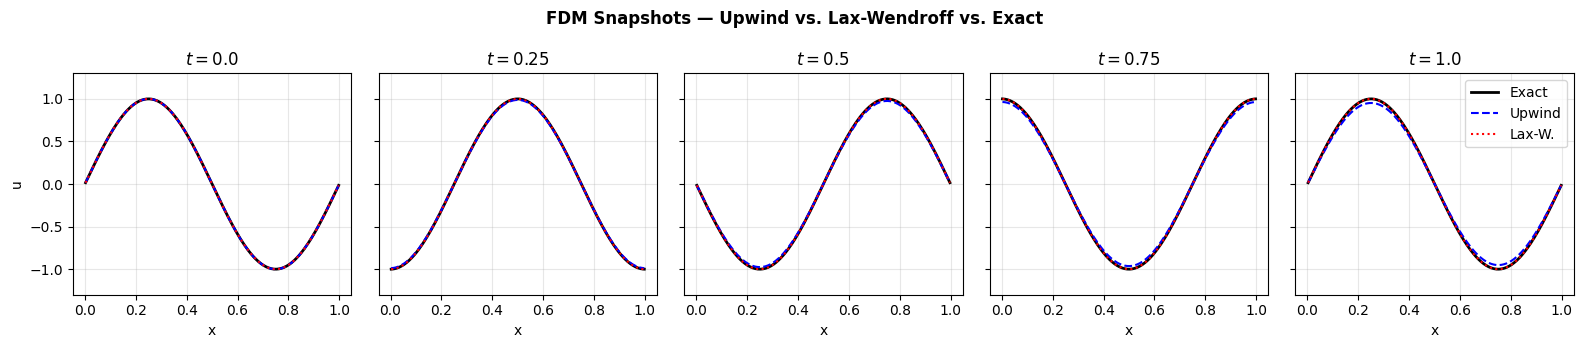

In [3]:
# ---- Snapshots at t = 0, 0.25, 0.5, 0.75, 1.0 ------------------------─
snap_times = [0.0, 0.25, 0.5, 0.75, 1.0]
snap_idx   = [int(round(ti / T * Nt)) for ti in snap_times]

fig, axes = plt.subplots(1, len(snap_times), figsize=(16, 3.5), sharey=True)
for ax, si, ti in zip(axes, snap_idx, snap_times):
    u_ex = u_exact(x_up, ti)
    ax.plot(x_up, u_ex,        "k-",  lw=2,   label="Exact")
    ax.plot(x_up, U_up[si],    "b--", lw=1.5, label="Upwind")
    ax.plot(x_lw, U_lw[si],    "r:",  lw=1.5, label="Lax-W.")
    ax.set_title(f"$t = {ti}$"); ax.set_xlabel("x")
    ax.set_ylim(-1.3, 1.3); ax.grid(alpha=0.3)
axes[0].set_ylabel("u"); axes[-1].legend(loc="upper right")
plt.suptitle("FDM Snapshots — Upwind vs. Lax-Wendroff vs. Exact", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

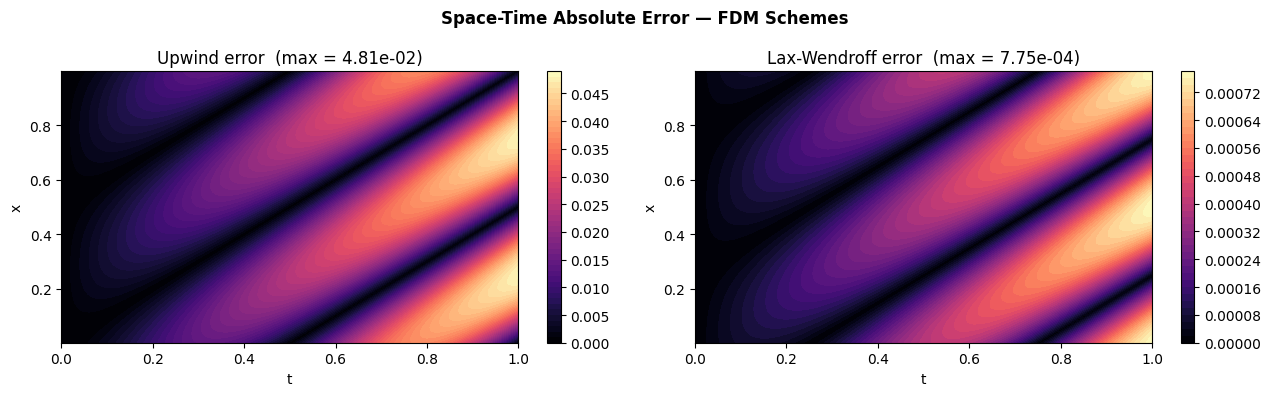

In [4]:
# ---- Space-time error maps -----------------------------------------------
U_exact_full = np.array([u_exact(x_up, ti) for ti in t_up])
err_up = np.abs(U_up - U_exact_full)
err_lw = np.abs(U_lw - U_exact_full)

# Subsample time axis for faster plotting (every 4th row)
s = 4
T_plot, X_plot = np.meshgrid(t_up[::s], x_up, indexing="ij")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, err, title in zip(axes,
                           [err_up[::s], err_lw[::s]],
                           ["Upwind error", "Lax-Wendroff error"]):
    cf = ax.contourf(T_plot, X_plot, err, levels=50, cmap="magma")
    ax.set_xlabel("t"); ax.set_ylabel("x")
    ax.set_title(f"{title}  (max = {err.max():.2e})")
    plt.colorbar(cf, ax=ax)

plt.suptitle("Space-Time Absolute Error — FDM Schemes", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

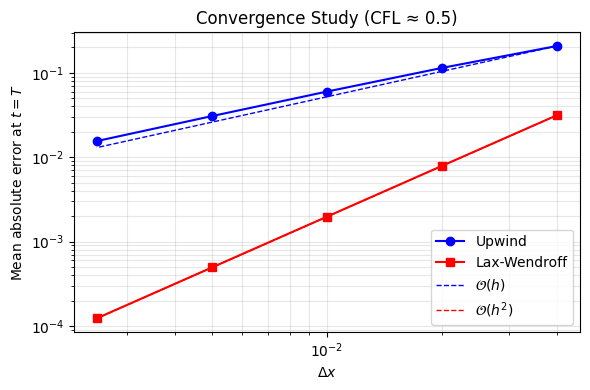

In [5]:
# ---- Grid-refinement convergence study -----------------------
Nx_list = [25, 50, 100, 200, 400]
err_up_conv, err_lw_conv = [], []

for nx in Nx_list:
    nt = 2 * nx           # keep CFL ≈ 0.5
    xu, _, Uu, _ = solve_upwind(Nx=nx, Nt=nt)
    xl, _, Ul, _ = solve_lax_wendroff(Nx=nx, Nt=nt)
    err_up_conv.append(np.mean(np.abs(Uu[-1] - u_exact(xu, T))))
    err_lw_conv.append(np.mean(np.abs(Ul[-1] - u_exact(xl, T))))

dx_list = [1.0 / nx for nx in Nx_list]

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(dx_list, err_up_conv, "bo-",  lw=1.5, label="Upwind")
ax.loglog(dx_list, err_lw_conv, "rs-",  lw=1.5, label="Lax-Wendroff")
# Reference lines
ax.loglog(dx_list, [dx**1 * err_up_conv[0] / dx_list[0]**1 for dx in dx_list],
          "b--", lw=1, label="$\\mathcal{O}(h)$")
ax.loglog(dx_list, [dx**2 * err_lw_conv[0] / dx_list[0]**2 for dx in dx_list],
          "r--", lw=1, label="$\\mathcal{O}(h^2)$")
ax.set_xlabel("$\\Delta x$"); ax.set_ylabel("Mean absolute error at $t = T$")
ax.set_title("Convergence Study (CFL ≈ 0.5)")
ax.legend(); ax.grid(which="both", alpha=0.3)
plt.tight_layout(); plt.show()

---

## Part 2 — Neural Network: Physics-Informed Neural Network (PINN)

### How It Works

A PINN treats $(x, t)$ as inputs and learns $\hat{u}_\theta(x, t)$ by minimising:

$$\mathcal{L} = \underbrace{\mathcal{L}_{IC}}_{\text{initial cond.}} + \underbrace{\mathcal{L}_{BC}}_{\text{periodic BC}} + \underbrace{\mathcal{L}_{PDE}}_{\text{physics residual}}$$

$$\mathcal{L}_{PDE} = \frac{1}{N_f}\sum_k \left(\frac{\partial\hat{u}}{\partial t}\bigg|_{(x_k,t_k)} + c\,\frac{\partial\hat{u}}{\partial x}\bigg|_{(x_k,t_k)}\right)^2$$

**Periodic boundary condition:**  
$\hat{u}(0, t) = \hat{u}(1, t)$ is enforced by adding  
$\mathcal{L}_{BC} = \text{MSE}\!\bigl(\hat{u}(0,t_k) - \hat{u}(1,t_k)\bigr)$

All derivatives are computed via `torch.autograd`.

**Training strategy:** Adam (warm-up) → L-BFGS (fine-tuning).


In [6]:
# ----------------------------------------------------------
# Network Architecture
# ----------------------------------------------------------
class TransportPINN(nn.Module):
    """Fully-connected PINN for the 1D transport equation.
    Input : (x, t) — 2D
    Output: u(x, t) — scalar
    Tanh activations required for smooth second-order autograd.
    """
    def __init__(self, hidden_layers=5, hidden_dim=64):
        super().__init__()
        layers = [nn.Linear(2, hidden_dim), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))


def grad1(u, v):
    return torch.autograd.grad(
        u, v, grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]


# ----------------------------------------------------------
# Training Point Sets
# ----------------------------------------------------------
N_IC  = 500    # initial condition points  (t = 0)
N_BC  = 300    # boundary points per side  (x = 0 and x = 1)
N_INT = 8000   # interior collocation points

# Initial condition  t = 0,  x ~ U[0,1]
x_ic = torch.rand(N_IC, 1)
t_ic = torch.zeros(N_IC, 1)
u_ic = torch.sin(2 * torch.pi * x_ic)   # u(x,0) = sin(2πx)

# Periodic BC:  sample matched t values for x=0 and x=1
t_bc = torch.rand(N_BC, 1)
x_bc_left  = torch.zeros(N_BC, 1)
x_bc_right = torch.ones(N_BC, 1)

# Interior collocation points
x_int = torch.rand(N_INT, 1, requires_grad=True)
t_int = torch.rand(N_INT, 1, requires_grad=True)

mse = nn.MSELoss()

print(f"IC  points : {N_IC}")
print(f"BC  points : {N_BC}  (per side)")
print(f"PDE points : {N_INT}")

IC  points : 500
BC  points : 300  (per side)
PDE points : 8000


In [7]:
def compute_loss(model, c=C):
    # ---- Initial condition loss -----------------------------------
    u_pred_ic = model(x_ic, t_ic)
    loss_ic = mse(u_pred_ic, u_ic)

    # ---- Periodic BC loss: u(0,t) = u(1,t) --------------------------------
    u_left  = model(x_bc_left,  t_bc)
    u_right = model(x_bc_right, t_bc)
    loss_bc = mse(u_left, u_right)

    # ---- PDE residual: u_t + c·u_x = 0 ----------------------------------------
    u_int = model(x_int, t_int)
    u_t   = grad1(u_int, t_int)
    u_x   = grad1(u_int, x_int)
    residual = u_t + c * u_x
    loss_pde = mse(residual, torch.zeros_like(residual))

    return loss_ic + loss_bc + loss_pde, loss_ic, loss_bc, loss_pde


# ---- Phase 1: Adam ---------------------------------------------------------------
model = TransportPINN(hidden_layers=5, hidden_dim=64)
opt_adam = optim.Adam(model.parameters(), lr=1e-3)
ADAM_EP  = 5000
history  = []

for ep in range(1, ADAM_EP + 1):
    opt_adam.zero_grad()
    loss, l_ic, l_bc, l_pde = compute_loss(model)
    loss.backward()
    opt_adam.step()
    history.append(loss.item())
    if ep % 1000 == 0:
        print(f"[Adam] Ep {ep:5d} | Loss {loss.item():.5f} | "
              f"IC {l_ic.item():.5f} | BC {l_bc.item():.5f} | PDE {l_pde.item():.5f}")

print("Adam phase done.")

[Adam] Ep  1000 | Loss 0.00007 | IC 0.00001 | BC 0.00001 | PDE 0.00004
[Adam] Ep  2000 | Loss 0.00002 | IC 0.00000 | BC 0.00001 | PDE 0.00001
[Adam] Ep  3000 | Loss 0.00001 | IC 0.00000 | BC 0.00000 | PDE 0.00001
[Adam] Ep  4000 | Loss 0.00001 | IC 0.00000 | BC 0.00000 | PDE 0.00000
[Adam] Ep  5000 | Loss 0.00001 | IC 0.00000 | BC 0.00001 | PDE 0.00000
Adam phase done.


In [8]:
# ---- Phase 2: L-BFGS fine-tuning -------------------------------─
opt_lbfgs = optim.LBFGS(
    model.parameters(),
    max_iter=500, tolerance_grad=1e-9, tolerance_change=1e-12,
    history_size=50, line_search_fn="strong_wolfe"
)

def closure():
    opt_lbfgs.zero_grad()
    loss, _, _, _ = compute_loss(model)
    loss.backward()
    history.append(loss.item())
    return loss

opt_lbfgs.step(closure)
final, _, _, _ = compute_loss(model)
print(f"L-BFGS done.  Final loss: {final.item():.6f}")

L-BFGS done.  Final loss: 0.000001


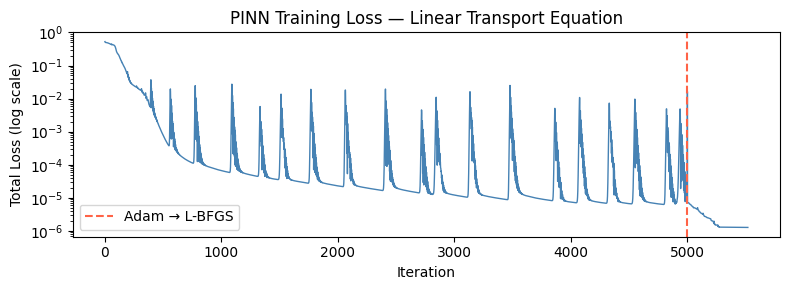

In [9]:
# Training loss curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(history, color="steelblue", lw=1.0)
ax.axvline(x=ADAM_EP, color="tomato", ls="--", lw=1.5, label="Adam → L-BFGS")
ax.set_xlabel("Iteration"); ax.set_ylabel("Total Loss (log scale)")
ax.set_title("PINN Training Loss — Linear Transport Equation")
ax.legend(); plt.tight_layout(); plt.show()

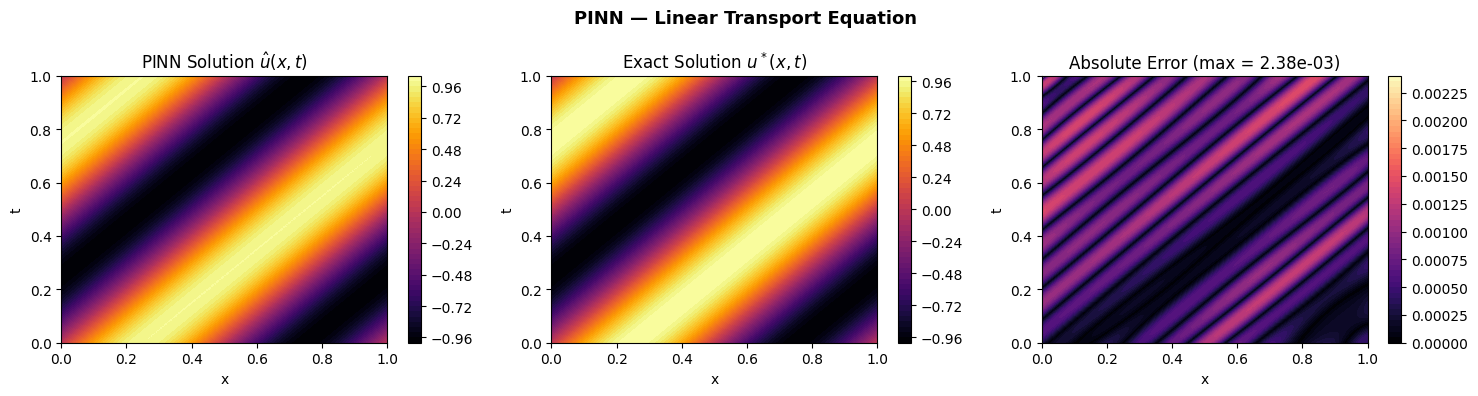

PINN — Max error: 2.38e-03  |  Mean error: 5.24e-04


In [10]:
# ---- Evaluate PINN on a dense (x, t) grid ------------------------------------
model.eval()
Nx_ev, Nt_ev = 200, 200
x_ev = np.linspace(0, 1, Nx_ev)
t_ev = np.linspace(0, T, Nt_ev)
X_ev, T_ev = np.meshgrid(x_ev, t_ev)   # shape (Nt_ev, Nx_ev)

xt = torch.tensor(X_ev.ravel(), dtype=torch.float32).unsqueeze(1)
tt = torch.tensor(T_ev.ravel(), dtype=torch.float32).unsqueeze(1)

with torch.no_grad():
    U_pinn_ev = model(xt, tt).numpy().reshape(Nt_ev, Nx_ev)

U_exact_ev = u_exact(X_ev, T_ev)
pinn_err   = np.abs(U_pinn_ev - U_exact_ev)

# Space-time contour of solution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cf0 = axes[0].contourf(X_ev, T_ev, U_pinn_ev, levels=50, cmap=CMAP)
axes[0].set_title("PINN Solution $\\hat{u}(x,t)$")
axes[0].set_xlabel("x"); axes[0].set_ylabel("t")
plt.colorbar(cf0, ax=axes[0])

cf1 = axes[1].contourf(X_ev, T_ev, U_exact_ev, levels=50, cmap=CMAP)
axes[1].set_title("Exact Solution $u^*(x,t)$")
axes[1].set_xlabel("x"); axes[1].set_ylabel("t")
plt.colorbar(cf1, ax=axes[1])

cf2 = axes[2].contourf(X_ev, T_ev, pinn_err, levels=50, cmap="magma")
axes[2].set_title(f"Absolute Error (max = {pinn_err.max():.2e})")
axes[2].set_xlabel("x"); axes[2].set_ylabel("t")
plt.colorbar(cf2, ax=axes[2])

plt.suptitle("PINN — Linear Transport Equation", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print(f"PINN — Max error: {pinn_err.max():.2e}  |  Mean error: {pinn_err.mean():.2e}")

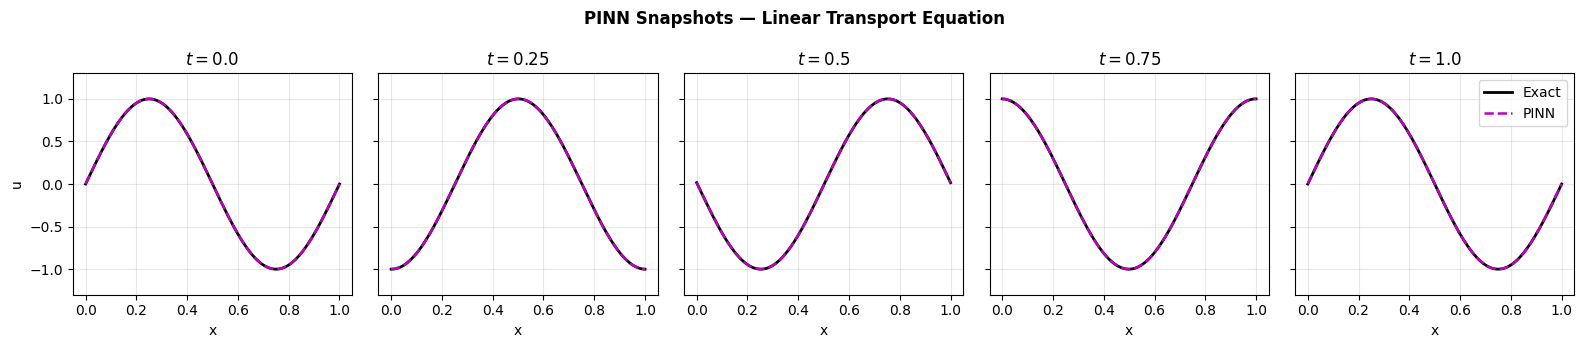

In [11]:
# ---- PINN snapshots at fixed times ---------------------------─
fig, axes = plt.subplots(1, len(snap_times), figsize=(16, 3.5), sharey=True)
for ax, ti in zip(axes, snap_times):
    ti_idx = int(round(ti / T * (Nt_ev - 1)))
    ax.plot(x_ev, U_exact_ev[ti_idx],  "k-",  lw=2,   label="Exact")
    ax.plot(x_ev, U_pinn_ev[ti_idx],   "m--", lw=1.8, label="PINN")
    ax.set_title(f"$t = {ti}$"); ax.set_xlabel("x")
    ax.set_ylim(-1.3, 1.3); ax.grid(alpha=0.3)
axes[0].set_ylabel("u"); axes[-1].legend(loc="upper right")
plt.suptitle("PINN Snapshots — Linear Transport Equation", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

---

## Part 3 — Side-by-Side Comparison

All three methods on the same axes at selected time snapshots and as space-time maps.


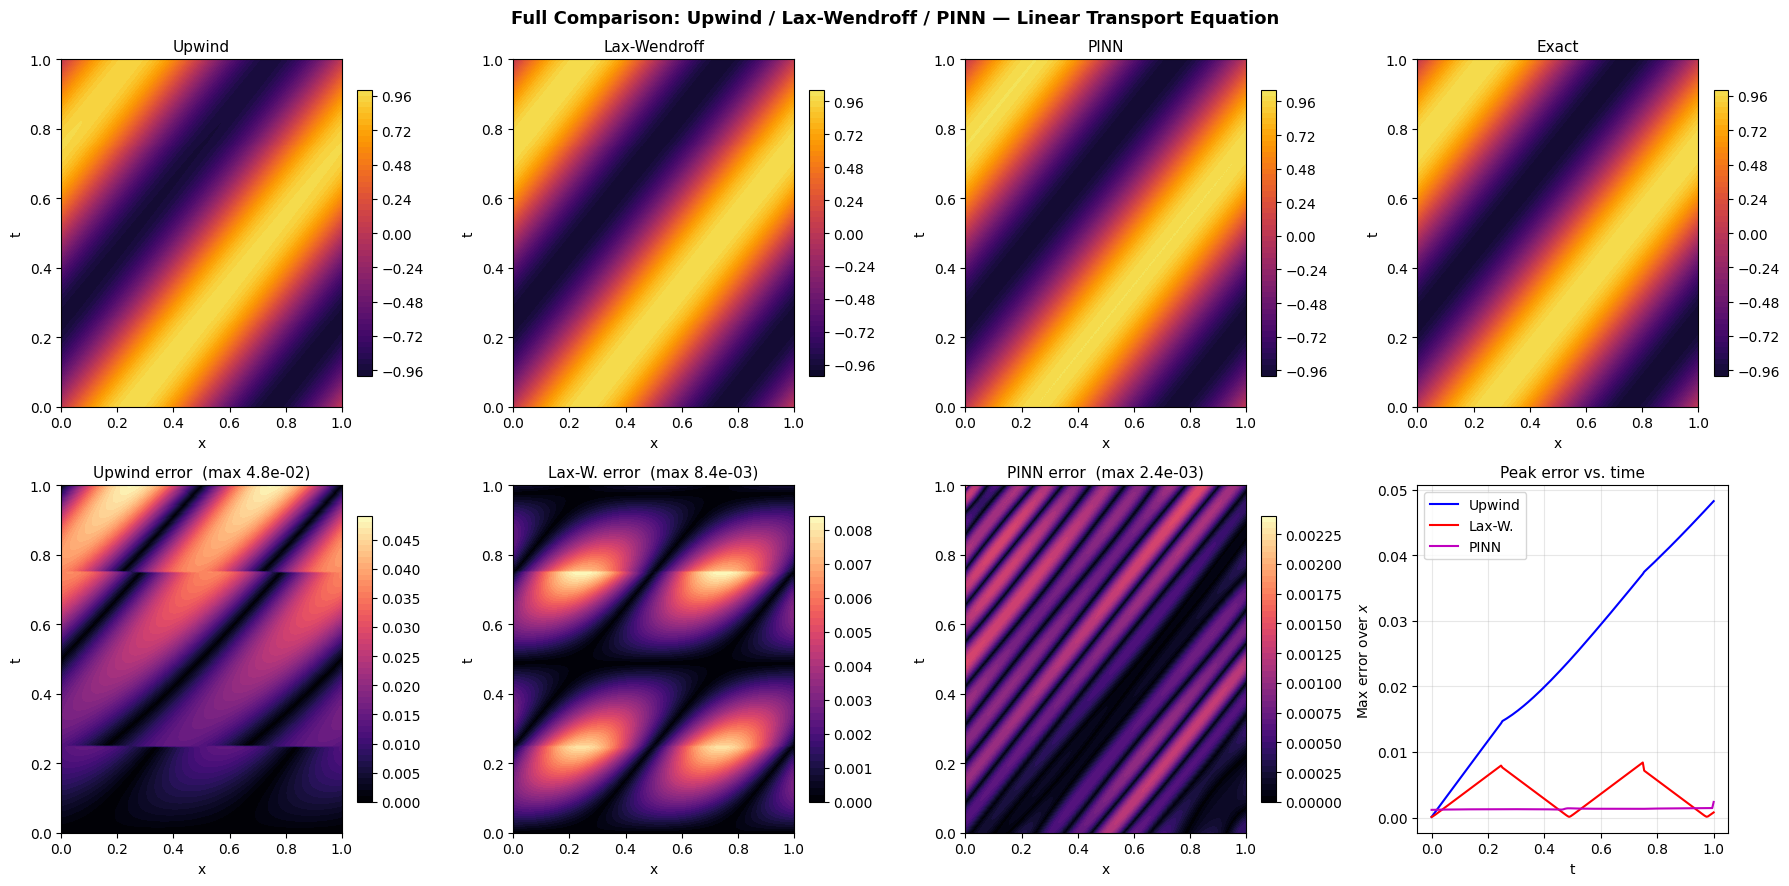

In [12]:
# Interpolate Upwind and Lax-Wendroff onto the dense evaluation grid
# Both FDM grids use cell centres; we interpolate onto x_ev (node-based)
from scipy.interpolate import interp1d

def interp_fdm_time(x_src, U_src, t_src, x_tgt, t_tgt):
    """Bilinear interpolation of an FDM solution onto a target (x,t) grid."""
    Nt_tgt, Nx_tgt = len(t_tgt), len(x_tgt)
    U_tgt = np.zeros((Nt_tgt, Nx_tgt))
    for i, ti in enumerate(t_tgt):
        # find nearest time index in source grid
        n_src = int(round(ti / T * (len(t_src) - 1)))
        f = interp1d(x_src, U_src[n_src], kind="linear",
                     fill_value="extrapolate")
        U_tgt[i] = f(x_tgt)
    return U_tgt

U_up_ev = interp_fdm_time(x_up, U_up, t_up, x_ev, t_ev)
U_lw_ev = interp_fdm_time(x_lw, U_lw, t_lw, x_ev, t_ev)
err_up_ev = np.abs(U_up_ev - U_exact_ev)
err_lw_ev = np.abs(U_lw_ev - U_exact_ev)

# ---- Space-time comparison: all methods ----------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

labels   = ["Upwind",  "Lax-Wendroff", "PINN",    "Exact"]
sols     = [U_up_ev,   U_lw_ev,        U_pinn_ev, U_exact_ev]
errs     = [err_up_ev, err_lw_ev,      pinn_err]
err_lbls = ["Upwind error", "Lax-W. error", "PINN error"]

for col, (lbl, sol) in enumerate(zip(labels, sols)):
    cf = axes[0, col].contourf(X_ev, T_ev, sol, levels=50, cmap=CMAP,
                                vmin=-1.2, vmax=1.2)
    axes[0, col].set_title(lbl, fontsize=11)
    axes[0, col].set_xlabel("x"); axes[0, col].set_ylabel("t")
    plt.colorbar(cf, ax=axes[0, col], fraction=0.046)

for col, (lbl, err) in enumerate(zip(err_lbls, errs)):
    cf = axes[1, col].contourf(X_ev, T_ev, err, levels=50, cmap="magma")
    axes[1, col].set_title(f"{lbl}  (max {err.max():.1e})", fontsize=11)
    axes[1, col].set_xlabel("x"); axes[1, col].set_ylabel("t")
    plt.colorbar(cf, ax=axes[1, col], fraction=0.046)

# Error-over-time curves in the 4th bottom panel
ax_et = axes[1, 3]
ax_et.plot(t_ev, err_up_ev.max(axis=1), "b-",  lw=1.5, label="Upwind")
ax_et.plot(t_ev, err_lw_ev.max(axis=1), "r-",  lw=1.5, label="Lax-W.")
ax_et.plot(t_ev, pinn_err.max(axis=1),  "m-",  lw=1.5, label="PINN")
ax_et.set_xlabel("t"); ax_et.set_ylabel("Max error over $x$")
ax_et.set_title("Peak error vs. time", fontsize=11)
ax_et.legend(); ax_et.grid(alpha=0.3)

fig.suptitle("Full Comparison: Upwind / Lax-Wendroff / PINN — Linear Transport Equation",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

Method                     Max error    Mean error      Order
--------------------------------------------------------------------
Upwind  (1st order)        4.824e-02     1.587e-02
Lax-Wendroff (2nd)         8.395e-03     2.435e-03
PINN                       2.384e-03     5.242e-04


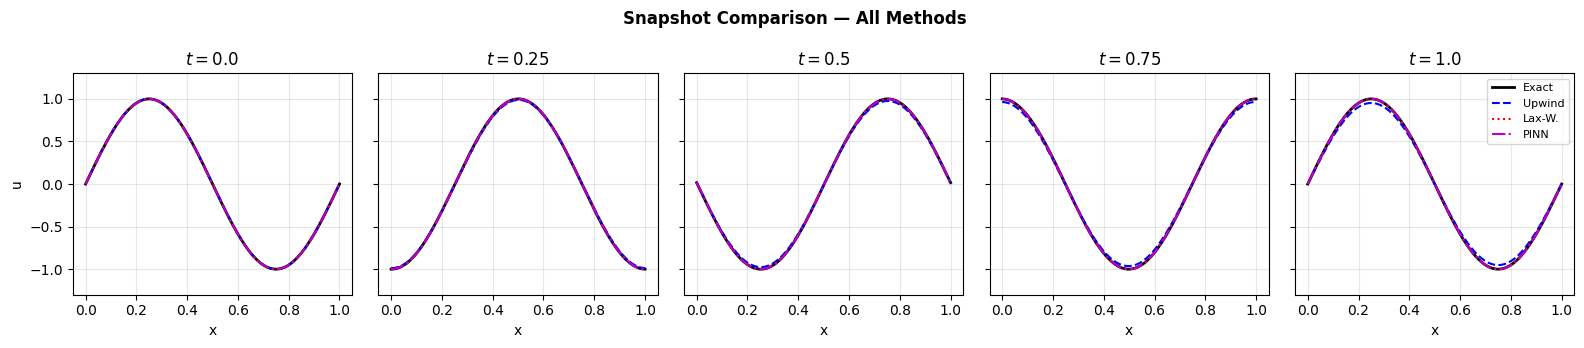

In [13]:
print("=" * 68)
print(f"{'Method':<22} {'Max error':>13} {'Mean error':>13} {'Order':>10}")
print("-" * 68)

methods = [
    ("Upwind  (1st order)", err_up_ev),
    ("Lax-Wendroff (2nd)",  err_lw_ev),
    ("PINN",                pinn_err),
]
for name, err in methods:
    print(f"{name:<22} {err.max():>13.3e} {err.mean():>13.3e}")

print("=" * 68)

# Snapshot comparison at t = T
fig, axes = plt.subplots(1, len(snap_times), figsize=(16, 3.5), sharey=True)
for ax, ti in zip(axes, snap_times):
    ti_idx = int(round(ti / T * (Nt_ev - 1)))
    ax.plot(x_ev, U_exact_ev[ti_idx],  "k-",  lw=2,   label="Exact")
    ax.plot(x_ev, U_up_ev[ti_idx],     "b--", lw=1.5, label="Upwind")
    ax.plot(x_ev, U_lw_ev[ti_idx],     "r:",  lw=1.5, label="Lax-W.")
    ax.plot(x_ev, U_pinn_ev[ti_idx],   "m-.", lw=1.5, label="PINN")
    ax.set_title(f"$t = {ti}$"); ax.set_xlabel("x")
    ax.set_ylim(-1.3, 1.3); ax.grid(alpha=0.3)
axes[0].set_ylabel("u"); axes[-1].legend(fontsize=8)
plt.suptitle("Snapshot Comparison — All Methods", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

---

## Summary

| Aspect | Upwind (FDM 1st) | Lax-Wendroff (FDM 2nd) | PINN |
|--------|-----------------|------------------------|------|
| **Accuracy** | $\mathcal{O}(\Delta t, \Delta x)$ | $\mathcal{O}(\Delta t^2, \Delta x^2)$ | Mesh-free; depends on training |
| **Stability condition** | CFL $\nu \leq 1$ | CFL $\|\nu\| \leq 1$ | Unconditional (no CFL limit) |
| **Numerical artefact** | Numerical diffusion (smearing) | Numerical dispersion (oscillations) | None by design |
| **Computational cost** | Very fast — explicit time-stepping | Very fast — explicit time-stepping | Slower — auto-diff back-prop |
| **Requires time-stepping** | Yes | Yes | No — solves over full $(x,t)$ domain at once |
| **Generalisation** | Fixed initial/boundary data | Fixed initial/boundary data | Embeds physics; can generalise over parameters |
| **Best use-case** | Smooth data, simple geometry | Smooth data, higher accuracy | Complex geometries, parametric studies, inverse problems |

### Observations

- **Upwind** is robust but first-order accurate — it artificially diffuses the wave, reducing its amplitude over time. The error grows linearly with $t$.
- **Lax-Wendroff** recovers second-order accuracy on smooth solutions, but produces Gibbs-like oscillations near steep gradients.
- **PINN** treats the whole space-time domain as a regression problem — no CFL constraint, no time-stepping — but requires careful tuning of loss weights and training hyperparameters for long-time or high-frequency wave problems.
